In [13]:
# =========================
# Imports & Configuration
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append(".")


plt.style.use("default")

In [16]:
# =========================
# Data Loading (Pipeline)
# =========================

from loader.pipeline import load_and_prepare_data

df = load_and_prepare_data()
df.head()


📂 Loading cached data...
✅ whale: 3012 rows
✅ market: 3012 rows
✅ btc: 4642 rows
✅ eth: 3812 rows
✅ funding: 3012 rows
🔧 Engineering features...
✅ Merged funding data: 3012 rows
✅ Created vol_ratio feature
✅ Features engineered: 55 columns, 3012 rows
📈 Defining all regimes (R0-R5)...
   R5 days detected: 786 (26.1%)

📊 Regime Distribution:
  🟢 R1:  338 ( 11.2%) | ⚪ R2:  345 ( 11.5%)
  🔴 R3:  327 ( 10.9%) | ⚪ R4:  223 (  7.4%)
  🔴 R5:  786 ( 26.1%) | ⚪ R0:  993 ( 33.0%)


,block_date,withdrawal_tx_count,std_whale_tx_size_eth,deposit_withdrawal_ratio,non_exchange_volume_eth,mega_whale_ratio,mega_whale_volume_eth,whale_volume_eth,non_exchange_ratio,net_flow_ma7,...,btc_vol30,btc_rsi,eth_btc_ratio,eth_btc_ratio_ma7,eth_btc_corr_30d,vol_ratio,regime_code,btc_regime,vol_regime,regime
0,2017-10-16 00:00:00+00:00,5.0,2310.607296,0.5146,3.382636e+05,0.8971,3.335630e+05,3.718084e+05,0.9098,10749.2728,...,0.0,0.0,0.057946,0.0,0.0,0.0,R0,NaN,LOW,nan_LOW
1,2017-10-17 00:00:00+00:00,15.0,13716.203240,1.5295,1.017314e+06,0.9456,1.055398e+06,1.116134e+06,0.9115,-20684.9471,...,0.0,0.0,0.056326,0.0,0.0,0.0,R0,NaN,LOW,nan_LOW
2,2017-10-18 00:00:00+00:00,5.0,3957.459236,1.6254,9.463566e+05,1.0000,9.872356e+05,9.872356e+05,0.9586,-15211.3463,...,0.0,0.0,0.056225,0.0,0.0,0.0,R0,NaN,LOW,nan_LOW
3,2017-10-19 00:00:00+00:00,6.0,2819.239036,0.1403,4.850454e+05,0.7803,4.221430e+05,5.409664e+05,0.8966,3912.9137,...,0.0,0.0,0.054153,0.0,0.0,0.0,R0,NaN,LOW,nan_LOW
4,2017-10-20 00:00:00+00:00,10.0,3236.014159,0.9605,6.113884e+05,0.8360,5.448516e+05,6.517544e+05,0.9381,3137.9499,...,0.0,0.0,0.050793,0.0,0.0,0.0,R0,NaN,LOW,nan_LOW


In [17]:
df.columns

Index(['block_date', 'withdrawal_tx_count', 'std_whale_tx_size_eth',
       'deposit_withdrawal_ratio', 'non_exchange_volume_eth',
       'mega_whale_ratio', 'mega_whale_volume_eth', 'whale_volume_eth',
       'non_exchange_ratio', 'net_flow_ma7', 'whale_exchange_withdrawals_eth',
       'exchange_volume_ratio', 'whale_exchange_deposits_eth',
       'non_exchange_tx_count', 'whale_tx_count', 'mega_whale_tx_count',
       'deposit_tx_count', 'whale_net_exchange_flow_eth', 'btc_price',
       'eth_price', 'eth_burned_zscore_90d', 'median_gas_delta_1d',
       'tx_per_active_zscore_90d', 'median_gas_delta_7d',
       'whale_exchange_asymmetry', 'eth_burned_delta_1d',
       'net_exchange_flow_ratio', 'whale_tx_zscore_90d',
       'whale_volume_ratio_delta_1d', 'whale_exchange_flow_ratio',
       'block_fullness_delta_1d', 'smart_contract_ratio_delta_1d',
       'tx_per_active_delta_1d', 'whale_volume_ratio', 'exchange_flow_share',
       'whale_volume_ratio_delta_3d', 'eth_funding_rate_8h

- Data Integrity Checks

In [19]:


print("Dataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3012 entries, 0 to 3011
Data columns (total 59 columns):
 #   Column                          Non-Null Count  Dtype              
---  ------                          --------------  -----              
 0   block_date                      3012 non-null   datetime64[ns, UTC]
 1   withdrawal_tx_count             3012 non-null   float64            
 2   std_whale_tx_size_eth           3012 non-null   float64            
 3   deposit_withdrawal_ratio        3012 non-null   float64            
 4   non_exchange_volume_eth         3012 non-null   float64            
 5   mega_whale_ratio                3012 non-null   float64            
 6   mega_whale_volume_eth           3012 non-null   float64            
 7   whale_volume_eth                3012 non-null   float64            
 8   non_exchange_ratio              3012 non-null   float64            
 9   net_flow_ma7                    3012 non-null   float64            
 10

In [20]:
print("\nMissing Values (Top 10):")
print(df.isna().sum().sort_values(ascending=False).head(10))



Missing Values (Top 10):
btc_regime                  6
withdrawal_tx_count         0
block_date                  0
deposit_withdrawal_ratio    0
non_exchange_volume_eth     0
mega_whale_ratio            0
mega_whale_volume_eth       0
whale_volume_eth            0
non_exchange_ratio          0
net_flow_ma7                0
dtype: int64


In [21]:
print("\nDistribution Summary:")
print(df.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))


Distribution Summary:
       withdrawal_tx_count  std_whale_tx_size_eth  deposit_withdrawal_ratio  \
count          3012.000000            3012.000000               3012.000000   
mean             16.021248            9659.519627                  2.456559   
std              22.545593           10483.167768                  3.118600   
min               0.000000             996.169341                  0.000000   
1%                2.000000            1957.205099                  0.258385   
5%                4.000000            2670.786222                  0.571040   
50%              12.000000            6682.398324                  1.719350   
95%              32.000000           26316.201995                  6.166675   
99%             132.780000           52096.298743                 13.903619   
max             322.000000          167197.516402                 59.401000   

       non_exchange_volume_eth  mega_whale_ratio  mega_whale_volume_eth  \
count             3.012000e+03  

In [ ]:
# Missing Value Summary

missing_summary = df.isna().sum()
missing_summary[missing_summary > 0]


btc_regime    6
dtype: int64

In [25]:
df["regime_code"].value_counts(normalize=True).sort_index()


regime_code
R0    0.329681
R1    0.112218
R2    0.114542
R3    0.108566
R4    0.074037
R5    0.260956
Name: proportion, dtype: float64

- A small number of missing values appear in derived regime labels due to rolling window requirements. 
- These rows are excluded during model training and backtesting to avoid leakage or artificial smoothing.

In [43]:
df = df.dropna(subset=["btc_regime"])

- Price Context

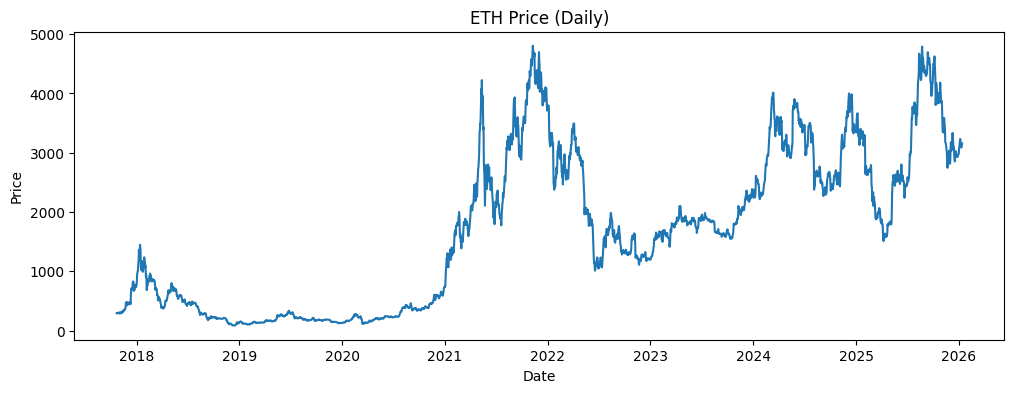

In [44]:

plt.figure(figsize=(12, 4))
plt.plot(df['block_date'], df['eth_price'])
plt.title("ETH Price (Daily)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()


- Feature Distributions

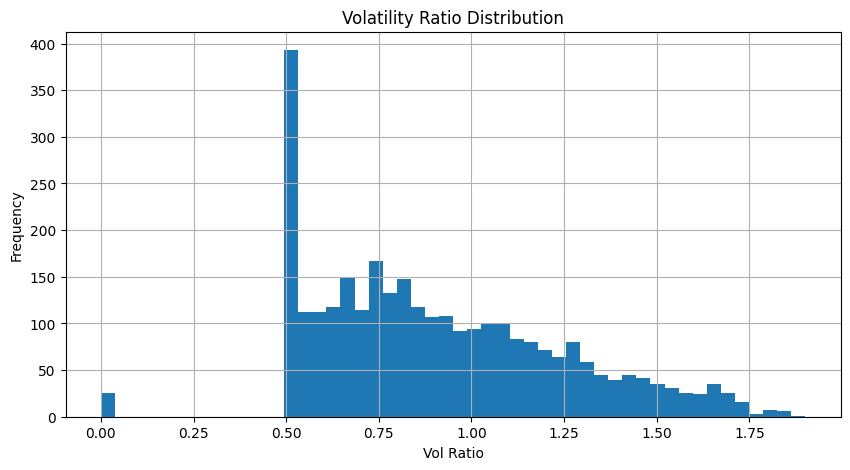

In [45]:

plt.figure(figsize=(10, 5))
df['vol_ratio'].hist(bins=50)
plt.title("Volatility Ratio Distribution")
plt.xlabel("Vol Ratio")
plt.ylabel("Frequency")
plt.show()

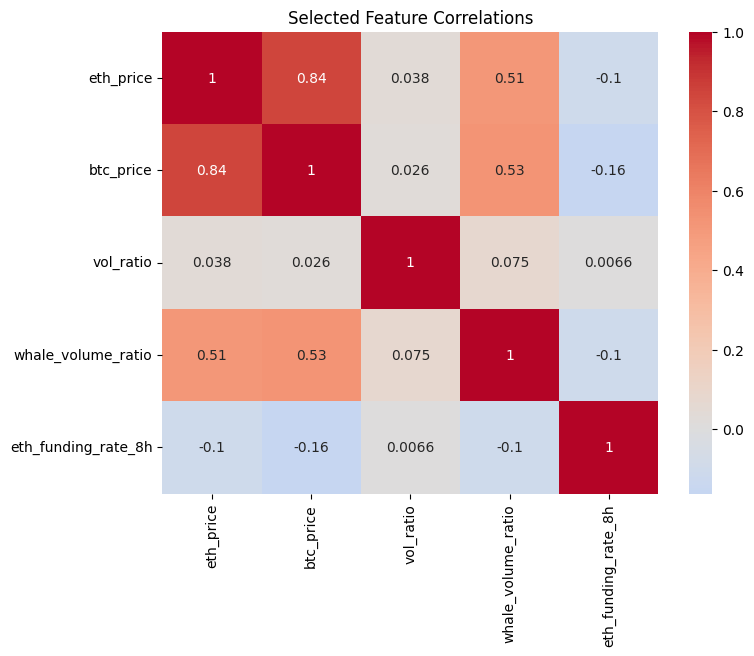

In [46]:
# =========================
# Feature Correlation (Selected)
# =========================

selected_features = [
    "eth_price",
    "btc_price",
    "vol_ratio",
    "whale_volume_ratio",
    "eth_funding_rate_8h"
]

corr_matrix = df[selected_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Selected Feature Correlations")
plt.show()


In [47]:
corr_matrix

,eth_price,btc_price,vol_ratio,whale_volume_ratio,eth_funding_rate_8h
eth_price,1.000000,0.841476,0.038078,0.512152,-0.102004
btc_price,0.841476,1.000000,0.026069,0.527004,-0.161818
vol_ratio,0.038078,0.026069,1.000000,0.075177,0.006589
whale_volume_ratio,0.512152,0.527004,0.075177,1.000000,-0.102558
eth_funding_rate_8h,-0.102004,-0.161818,0.006589,-0.102558,1.000000



Regime Distribution (Proportions):
regime_code
R0    0.328343
R5    0.261477
R2    0.114770
R1    0.112442
R3    0.108782
R4    0.074185
Name: proportion, dtype: float64


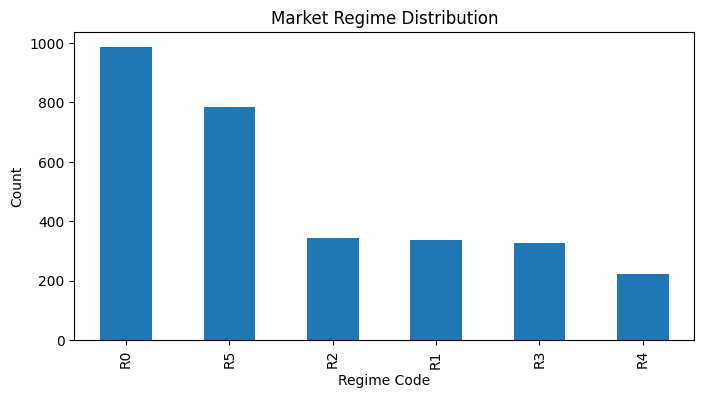


R5 regime occurrences: 786 (26.15%)


In [48]:
# =========================
# Regime Analysis
# =========================

print("\nRegime Distribution (Proportions):")
print(df["regime_code"].value_counts(normalize=True))

plt.figure(figsize=(8, 4))
df["regime_code"].value_counts().plot(kind="bar")
plt.title("Market Regime Distribution")
plt.xlabel("Regime Code")
plt.ylabel("Count")
plt.show()

# R5 specific analysis
r5_count = (df["regime_code"] == "R5").sum()
print(f"\nR5 regime occurrences: {r5_count} ({r5_count/len(df)*100:.2f}%)")

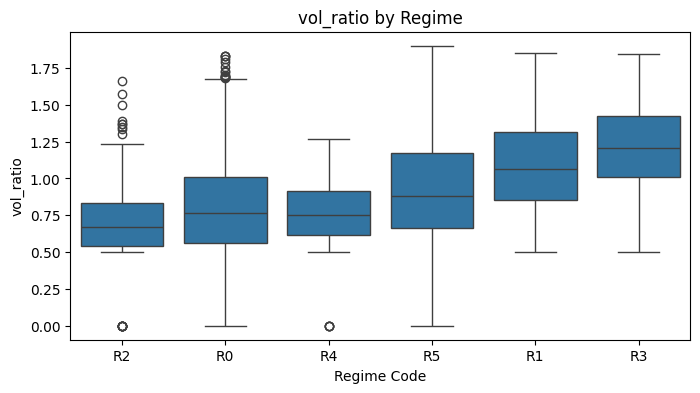

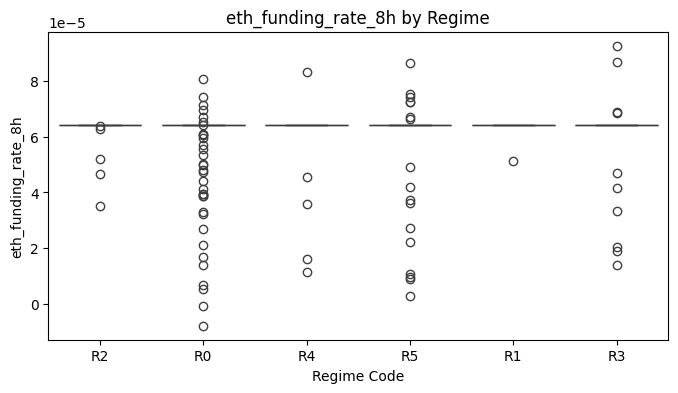

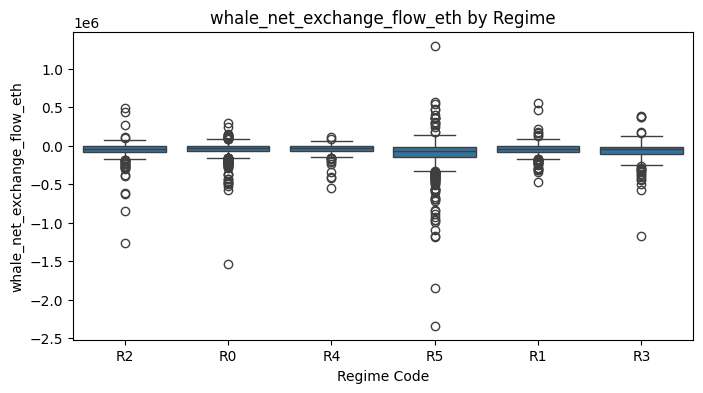

In [49]:

# =========================
# Feature Behavior by Regime
# =========================

core_features = ["vol_ratio", "eth_funding_rate_8h", "whale_net_exchange_flow_eth"]

for feature in core_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x="regime_code", y=feature, data=df)
    plt.title(f"{feature} by Regime")
    plt.xlabel("Regime Code")
    plt.ylabel(feature)
    plt.show()

#### Feature Importance Analysis

Feature importance analysis is used to:
- validate that the model relies on economically meaningful signals
- detect unstable or spurious drivers
- confirm alignment with regime-based intuition

Two complementary approaches are used:
1. Linear model coefficients (directional influence)
2. Tree-based feature importance (non-linear influence)

These analyses are performed **after feature engineering and regime labeling**
but **before deployment or live trading**.


In [50]:
# =========================
# Supervised Dataset
# =========================

# NOTE:
# Targets are created explicitly here for model evaluation only.
# All feature engineering and regime labeling are done upstream.

from pipeline.pipeline_builder import build_pipeline_complete
from loader.data_loader import load_cached_data

df_whales, df_market, df_btc, df_eth, df_funding = load_cached_data()

df_supervised = build_pipeline_complete(
    df_whales,
    df_market,
    df_btc,
    df_eth,
    df_funding
)

df_supervised.head()


📂 Loading cached data...
✅ whale: 3012 rows
✅ market: 3012 rows
✅ btc: 4642 rows
✅ eth: 3812 rows
✅ funding: 3012 rows
🔧 Engineering features...
✅ Merged funding data: 3012 rows
✅ Created vol_ratio feature
✅ Features engineered: 55 columns, 3012 rows
🎯 Creating two-tier targets...

📊 Target Distribution (Two-Tier SHORT):
  DOWN :  498 ( 16.5%)
  FLAT : 1921 ( 63.8%)
  UP   :  593 ( 19.7%)

  Tier 1 (crash):      229
  Tier 2 (breakdown):  302
  Total DOWN:          498
📈 Defining all regimes (R0-R5)...
   R5 days detected: 786 (26.1%)

📊 Regime Distribution:
  🟢 R1:  338 ( 11.2%) | ⚪ R2:  345 ( 11.5%)
  🔴 R3:  327 ( 10.9%) | ⚪ R4:  223 (  7.4%)
  🔴 R5:  786 ( 26.1%) | ⚪ R0:  993 ( 33.0%)


,block_date,withdrawal_tx_count,std_whale_tx_size_eth,deposit_withdrawal_ratio,non_exchange_volume_eth,mega_whale_ratio,mega_whale_volume_eth,whale_volume_eth,non_exchange_ratio,net_flow_ma7,...,rolling_vol_30,return_t2,threshold_t2,target_t2,y_long_t2,y_short_t2,regime_code,btc_regime,vol_regime,regime
0,2017-10-16 00:00:00+00:00,5.0,2310.607296,0.5146,3.382636e+05,0.8971,3.335630e+05,3.718084e+05,0.9098,10749.2728,...,NaN,-0.054190,NaN,0,0,0,R0,NaN,LOW,nan_LOW
1,2017-10-17 00:00:00+00:00,15.0,13716.203240,1.5295,1.017314e+06,0.9456,1.055398e+06,1.116134e+06,0.9115,-20684.9471,...,NaN,-0.030091,NaN,0,0,0,R0,NaN,LOW,nan_LOW
2,2017-10-18 00:00:00+00:00,5.0,3957.459236,1.6254,9.463566e+05,1.0000,9.872356e+05,9.872356e+05,0.9586,-15211.3463,...,NaN,-0.039239,NaN,0,0,0,R0,NaN,LOW,nan_LOW
3,2017-10-19 00:00:00+00:00,6.0,2819.239036,0.1403,4.850454e+05,0.7803,4.221430e+05,5.409664e+05,0.8966,3912.9137,...,NaN,-0.025547,NaN,0,0,0,R0,NaN,LOW,nan_LOW
4,2017-10-20 00:00:00+00:00,10.0,3236.014159,0.9605,6.113884e+05,0.8360,5.448516e+05,6.517544e+05,0.9381,3137.9499,...,NaN,-0.022978,NaN,0,0,0,R0,NaN,LOW,nan_LOW


In [52]:
# =========================
# Feature / Target Split
# =========================

TARGET_COL = "target_t2"   # or your actual target name

FEATURE_COLS = [
    col for col in df_supervised.columns
    if col not in [
        "block_date",
        TARGET_COL,
        "regime",
        "regime_code",
        "btc_regime",
        "vol_regime"
    ]
]

X = df_supervised[FEATURE_COLS]
y = df_supervised[TARGET_COL]

print("Features:", len(FEATURE_COLS))
print("Samples:", len(X))


Features: 59
Samples: 3012


In [54]:
# =========================
# Time-Series Split
# =========================

split_idx = int(len(X) * 0.8)

X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]

X_train.shape, X_val.shape


((2409, 59), (603, 59))

In [55]:
# =========================
# Data for Feature Importance
# =========================

X_train, X_val, y_train, y_val  


(      withdrawal_tx_count  std_whale_tx_size_eth  deposit_withdrawal_ratio  \
 0                     5.0            2310.607296                    0.5146   
 1                    15.0           13716.203240                    1.5295   
 2                     5.0            3957.459236                    1.6254   
 3                     6.0            2819.239036                    0.1403   
 4                    10.0            3236.014159                    0.9605   
 ...                   ...                    ...                       ...   
 2404                 15.0            8437.086701                    1.7057   
 2405                  9.0            2538.278252                    1.1404   
 2406                  6.0            1961.152244                    1.4987   
 2407                  6.0            3207.918277                    1.7171   
 2408                 16.0            3370.005830                    1.8662   
 
       non_exchange_volume_eth  mega_whale_ratio  

In [59]:
from sklearn.linear_model import LogisticRegression

lin_model = LogisticRegression(max_iter=1000)
lin_model.fit(X_train, y_train)

coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": lin_model.coef_[0]
}).sort_values("coefficient", ascending=False)

coef_df.head(10)


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values